In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [3]:
# Load the dataset

data = pd.read_csv("heart.csv")


In [4]:
# Display first 5 rows

print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [5]:
# Basic EDA

print("\nShape of the dataset:")
print(data.shape)

print("\nDataset Information:")
print(data.info())

print("\nStatistical Description:")
print(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Values:")
print(data.duplicated().sum())


Shape of the dataset:
(303, 14)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Statistical Description:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.00000

In [6]:
# Data Preprocessing

# Remove duplicate rows
data = data.drop_duplicates()

print("\nShape after removing duplicates:")
print(data.shape)



Shape after removing duplicates:
(302, 14)


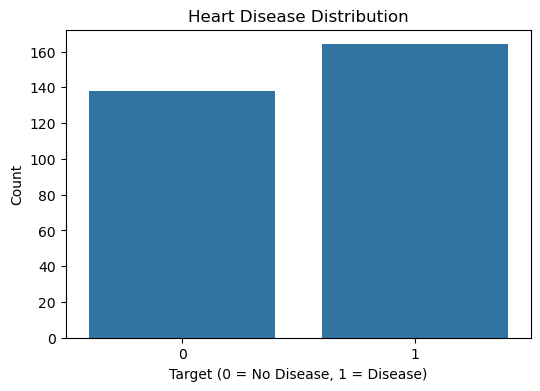

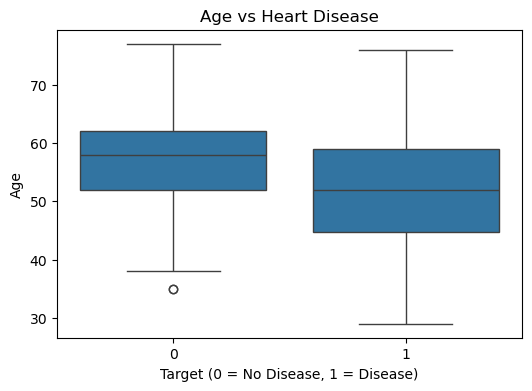

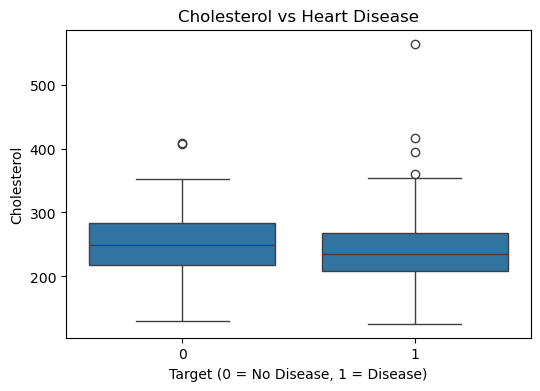

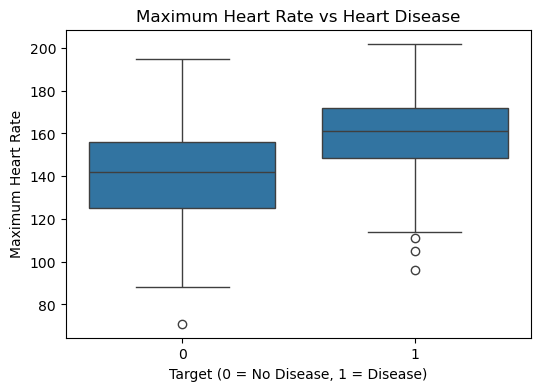

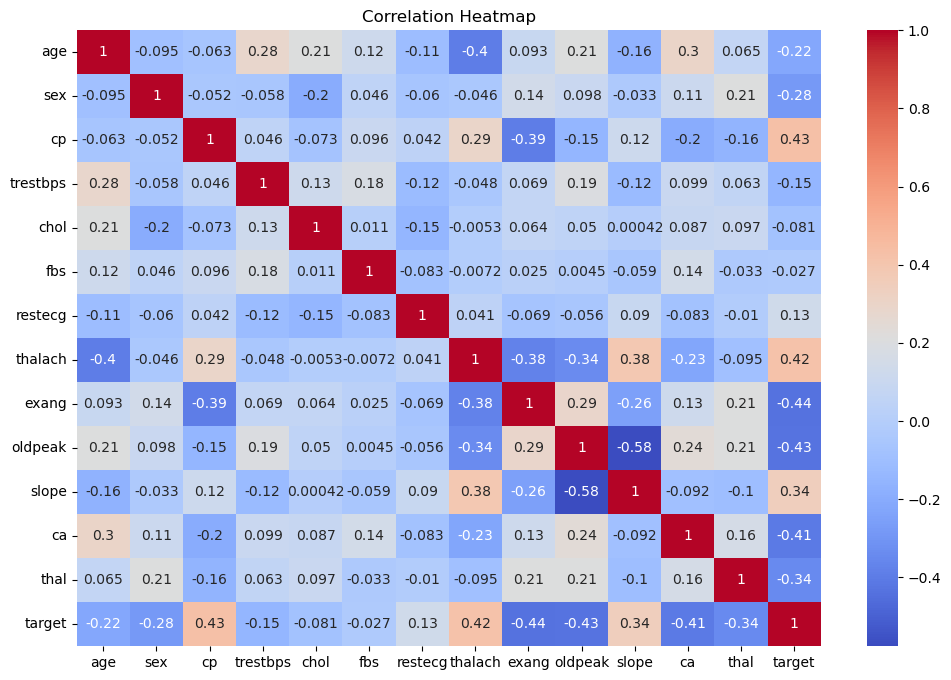

In [7]:
# Exploratory Data Analysis

# Heart disease distribution

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=data)
plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()


# Age vs Heart Disease

plt.figure(figsize=(6, 4))
sns.boxplot(x="target", y="age", data=data)
plt.title("Age vs Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Age")
plt.show()


# Cholesterol vs Heart Disease

plt.figure(figsize=(6, 4))
sns.boxplot(x="target", y="chol", data=data)
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Cholesterol")
plt.show()


# Maximum Heart Rate vs Heart Disease

plt.figure(figsize=(6, 4))
sns.boxplot(x="target", y="thalach", data=data)
plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Maximum Heart Rate")
plt.show()


# Correlation Heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [8]:
# Define Features and Target

X = data.drop("target", axis=1)
y = data["target"]

In [9]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# Create Gaussian Naive Bayes Classifier

model = GaussianNB()

In [11]:
# Train the model

model.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [12]:
# Make Predictions

y_pred = model.predict(X_test)



In [18]:
# Evaluating the model

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:\n")
print(accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)


Accuracy:

0.819672131147541

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61


Confusion Matrix:

[[20  8]
 [ 3 30]]


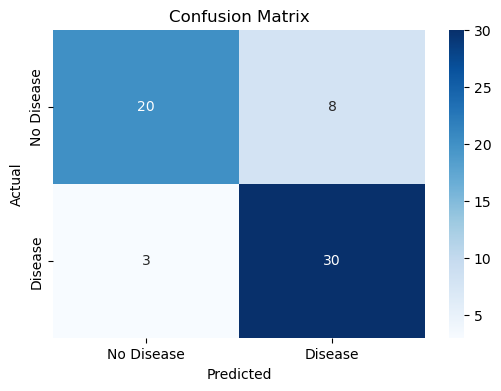

In [19]:
# Display Confusion Matrix Graphically

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
# Predict Heart Disease for a Sample Patient

sample_patient = pd.DataFrame([[
    55,     # age
    1,      # sex
    1,      # cp
    130,    # trestbps
    250,    # chol
    0,      # fbs
    1,      # restecg
    150,    # thalach
    0,      # exang
    1.0,    # oldpeak
    2,      # slope
    0,      # ca
    2       # thal
]], columns=X.columns)

sample_prediction = model.predict(sample_patient)

In [22]:
# Display result

print("\nSample Patient Prediction:")
if sample_prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")


Sample Patient Prediction:
Heart Disease Detected
